In [27]:
import numpy as np
import matplotlib.pyplot as plt
from config import ALPHA, L_HEAT, T_HEAT

datos_fdm = np.load('heat_fdm_resultado.npz')
x = datos_fdm['x']
u_fdm = datos_fdm['u_fdm_final']
u_exacta = datos_fdm['u_exacta']

datos_fdm = np.load('heat_fdm_resultado_inestable.npz')
x = datos_fdm['x']
u_fdm_inestable = datos_fdm['u_fdm_final']
u_exacta = datos_fdm['u_exacta']

datos_pinn = np.load('heat_pinn_resultado.npz')
u_pinn = datos_pinn['u_pinn']
error_l2_pinn = float(datos_pinn['error_l2_pinn'])
loss_steps = datos_pinn['loss_steps']
loss_total = datos_pinn['loss_total']

# Error del FDM recalculado desde archivo (no hace falta reejecutar el solver)
error_l2_fdm = np.linalg.norm(u_fdm - u_exacta) / np.linalg.norm(u_exacta)
error_l2_fdm_inestable = np.linalg.norm(u_fdm_inestable - u_exacta) / np.linalg.norm(u_exacta)

print(f"Error L2 relativo FDM  : {error_l2_fdm:.6f}")
print(f"Error L2 relativo FDM inestable : {error_l2_fdm_inestable}")
print(f"Error L2 relativo PINN : {error_l2_pinn:.6f}")

Error L2 relativo FDM  : 0.000325
Error L2 relativo FDM inestable : 1.0761871981312655e+106
Error L2 relativo PINN : 0.000864


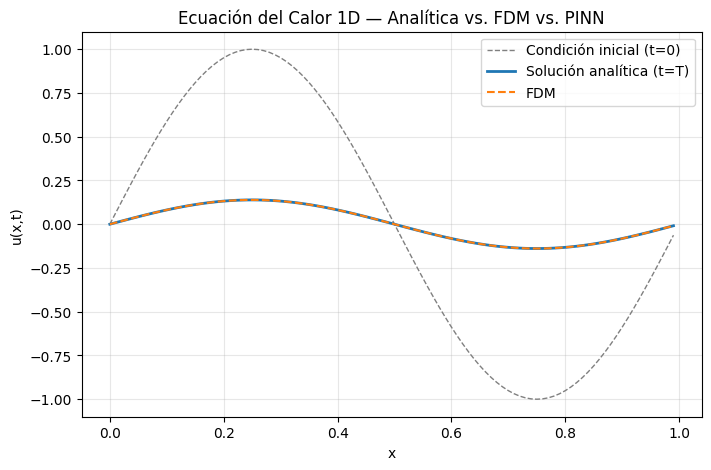

In [28]:
u0 = np.sin(2 * np.pi * x / L_HEAT)

plt.figure(figsize=(8, 5))
plt.plot(x, u0, '--', color='gray', linewidth=1, label='Condición inicial (t=0)')
plt.plot(x, u_exacta, '-', linewidth=2, label='Solución analítica (t=T)')
plt.plot(x, u_fdm, '--', linewidth=1.5, label=f'FDM')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title('Ecuación del Calor 1D — Analítica vs. FDM vs. PINN')
plt.grid(True, alpha=0.3)
plt.show()

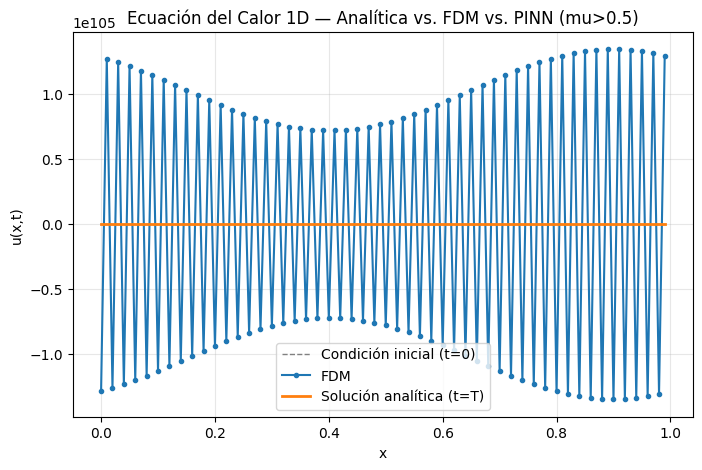

In [29]:
u0 = np.sin(2 * np.pi * x / L_HEAT)

plt.figure(figsize=(8, 5))
plt.plot(x, u0, '--', color='gray', linewidth=1, label='Condición inicial (t=0)')
plt.plot(x, u_fdm_inestable, 'o-', markersize=3, label=f'FDM')
plt.plot(x, u_exacta, '-', linewidth=2, label='Solución analítica (t=T)')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title('Ecuación del Calor 1D — Analítica vs. FDM vs. PINN (mu>0.5)')
plt.grid(True, alpha=0.3)
plt.show()

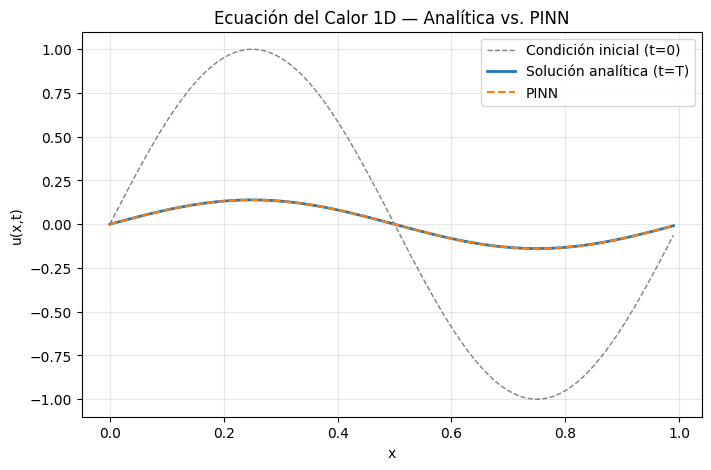

In [30]:
u0 = np.sin(2 * np.pi * x / L_HEAT)

plt.figure(figsize=(8, 5))
plt.plot(x, u0, '--', color='gray', linewidth=1, label='Condición inicial (t=0)')
plt.plot(x, u_exacta, '-', linewidth=2, label='Solución analítica (t=T)')
plt.plot(x, u_pinn, '--', linewidth=1.5, label=f'PINN')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title('Ecuación del Calor 1D — Analítica vs. PINN')
plt.grid(True, alpha=0.3)
plt.show()

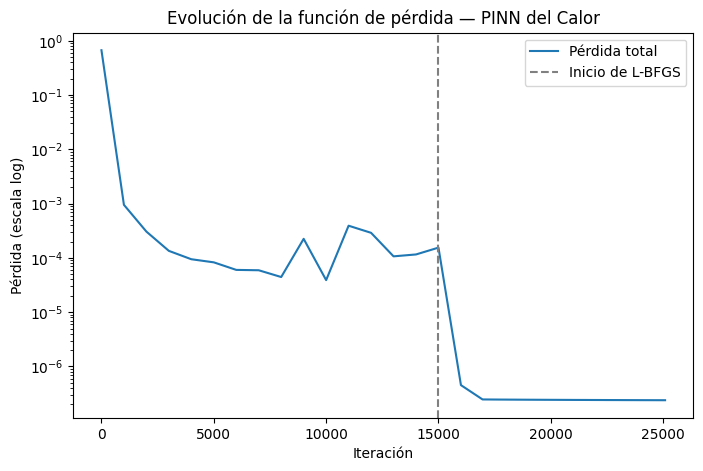

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(loss_steps, loss_total, label='Pérdida total')
plt.axvline(x=15000, color='gray', linestyle='--', label='Inicio de L-BFGS')
plt.yscale('log')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (escala log)')
plt.legend()
plt.title('Evolución de la función de pérdida — PINN del Calor')
plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt

nu_valores = [0.05, 0.03, 0.02, 0.015, 0.01, 0.0075, 0.005, 0.001]

# Errores del FDM (malla normal Nx=200) — del barrido que ya hiciste
errores_fdm = [0.000533, 0.001241, 0.002270, 0.003478, 0.006465,0.010311, 0.021775, np.nan]

# Errores de la PINN — cargados de los .npz
errores_pinn = []
for NU in nu_valores:
    datos = np.load(f'burgers_pinn_resultado_nu{NU}.npz')
    errores_pinn.append(float(datos['error_l2_pinn']))

# Péclet de malla del FDM (Nx=200)
peclet = [1.0 * 2.0 / 200 / nu for nu in nu_valores]

print(f"{'nu':>8} {'Pe':>6} {'Error FDM':>12} {'Error PINN':>12} {'Ratio':>8}")
print("-" * 50)
for i, nu in enumerate(nu_valores):
    ratio = errores_fdm[i] / errores_pinn[i]
    print(f"{nu:>8} {peclet[i]:>6.2f} {errores_fdm[i]:>12.6f} {errores_pinn[i]:>12.6f} {ratio:>8.1f}x")

      nu     Pe    Error FDM   Error PINN    Ratio
--------------------------------------------------
    0.05   0.20     0.000533     0.000186      2.9x
    0.03   0.33     0.001241     0.000167      7.4x
    0.02   0.50     0.002270     0.000132     17.2x
   0.015   0.67     0.003478     0.000256     13.6x
    0.01   1.00     0.006465     0.000262     24.7x
  0.0075   1.33     0.010311     0.000611     16.9x
   0.005   2.00     0.021775     0.003293      6.6x
   0.001  10.00          nan     0.353396      nanx


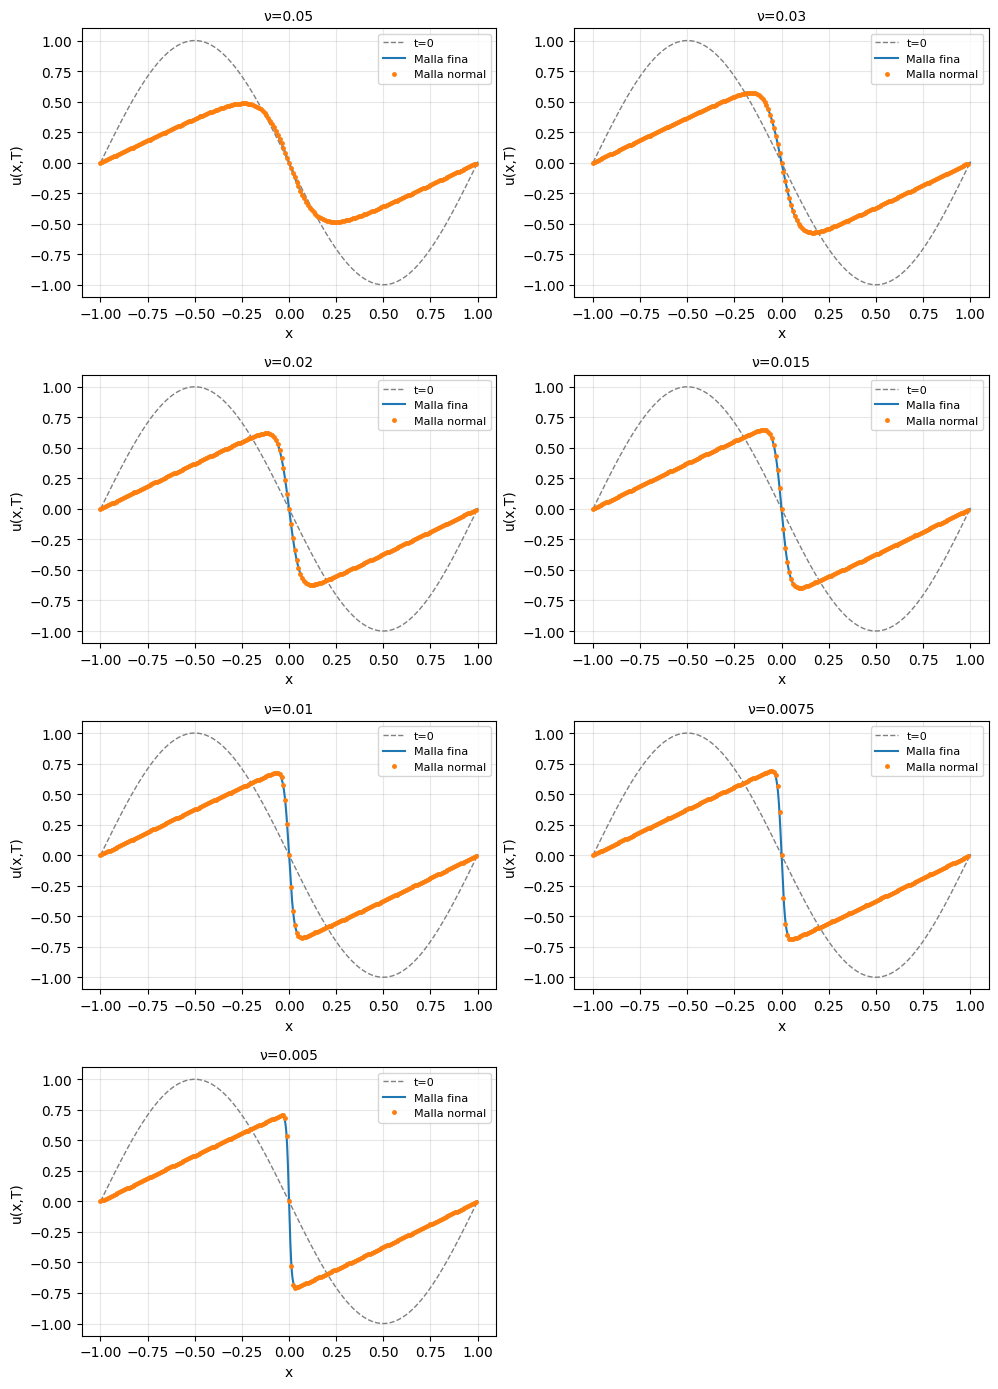

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from config import NT_BURGERS, NX_BURGERS, T_BURGERS, X_MAX_BURGERS, X_MIN_BURGERS

datos = np.load('burgers_referencias_ultimo_t.npz')
nu_valores = [0.05, 0.03, 0.02, 0.015, 0.01, 0.0075, 0.005]

# Cambiamos a 4 filas y 2 columnas (proporción vertical ajustada)
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for i, nu in enumerate(nu_valores):
    x_norm = datos[f"x_normal{nu}"]
    U_norm = datos[f"U_normal{nu}"]
    x_ref = datos[f'x_ref_nu{nu}']
    u_ref = datos[f'u_ref_nu{nu}']
    err = float(datos[f'error_l2_nu{nu}'])
    pe = float(datos[f'peclet_nu{nu}'])

    ax = axes[i]
    ax.plot(
        x_ref,
        -np.sin(np.pi * x_ref),
        '--',
        color='gray',
        linewidth=1,
        label='t=0',
    )
    ax.plot(x_ref, u_ref, '-', linewidth=1.5, label='Malla fina')
    ax.plot(x_norm, U_norm, 'o', markersize=2.5, label='Malla normal')
    ax.set_title(f'ν={nu}', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,T)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Oculta el octavo subplot sobrante (el índice 7)
for j in range(len(nu_valores), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [48]:
# PESOS DE LAS REFERENCIAS SUPERFINAS
import os, glob

archivos = sorted(glob.glob('burgers_referencia_nu_super_fina*.npz'))
total = 0
for f in archivos:
    tam = os.path.getsize(f)
    total += tam
    print(f"{f:>45}  {tam/1e9:>8.2f} GB")

print("-" * 60)
print(f"{'TOTAL':>45}  {total/1e9:>8.2f} GB")

    burgers_referencia_nu_super_fina0.001.npz      6.40 GB
    burgers_referencia_nu_super_fina0.005.npz      6.40 GB
   burgers_referencia_nu_super_fina0.0075.npz      6.40 GB
     burgers_referencia_nu_super_fina0.01.npz      6.40 GB
    burgers_referencia_nu_super_fina0.015.npz      6.40 GB
     burgers_referencia_nu_super_fina0.02.npz      6.40 GB
     burgers_referencia_nu_super_fina0.03.npz      6.40 GB
     burgers_referencia_nu_super_fina0.05.npz      6.40 GB
------------------------------------------------------------
                                        TOTAL     51.20 GB


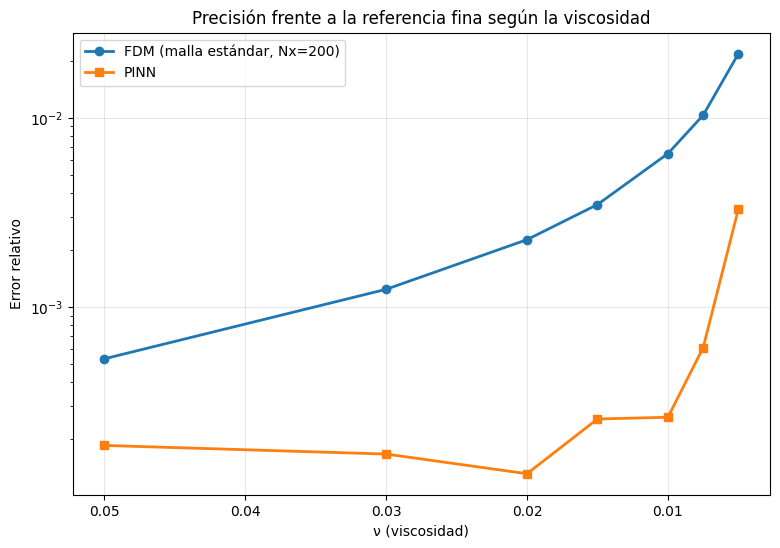

In [34]:
plt.figure(figsize=(9, 6))
plt.plot(nu_valores, errores_fdm, 'o-', label='FDM (malla estándar, Nx=200)', linewidth=2)
plt.plot(nu_valores, errores_pinn, 's-', label='PINN', linewidth=2)
plt.yscale('log')
plt.gca().invert_xaxis()
plt.xlabel('ν (viscosidad)')
plt.ylabel('Error relativo')
plt.title('Precisión frente a la referencia fina según la viscosidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

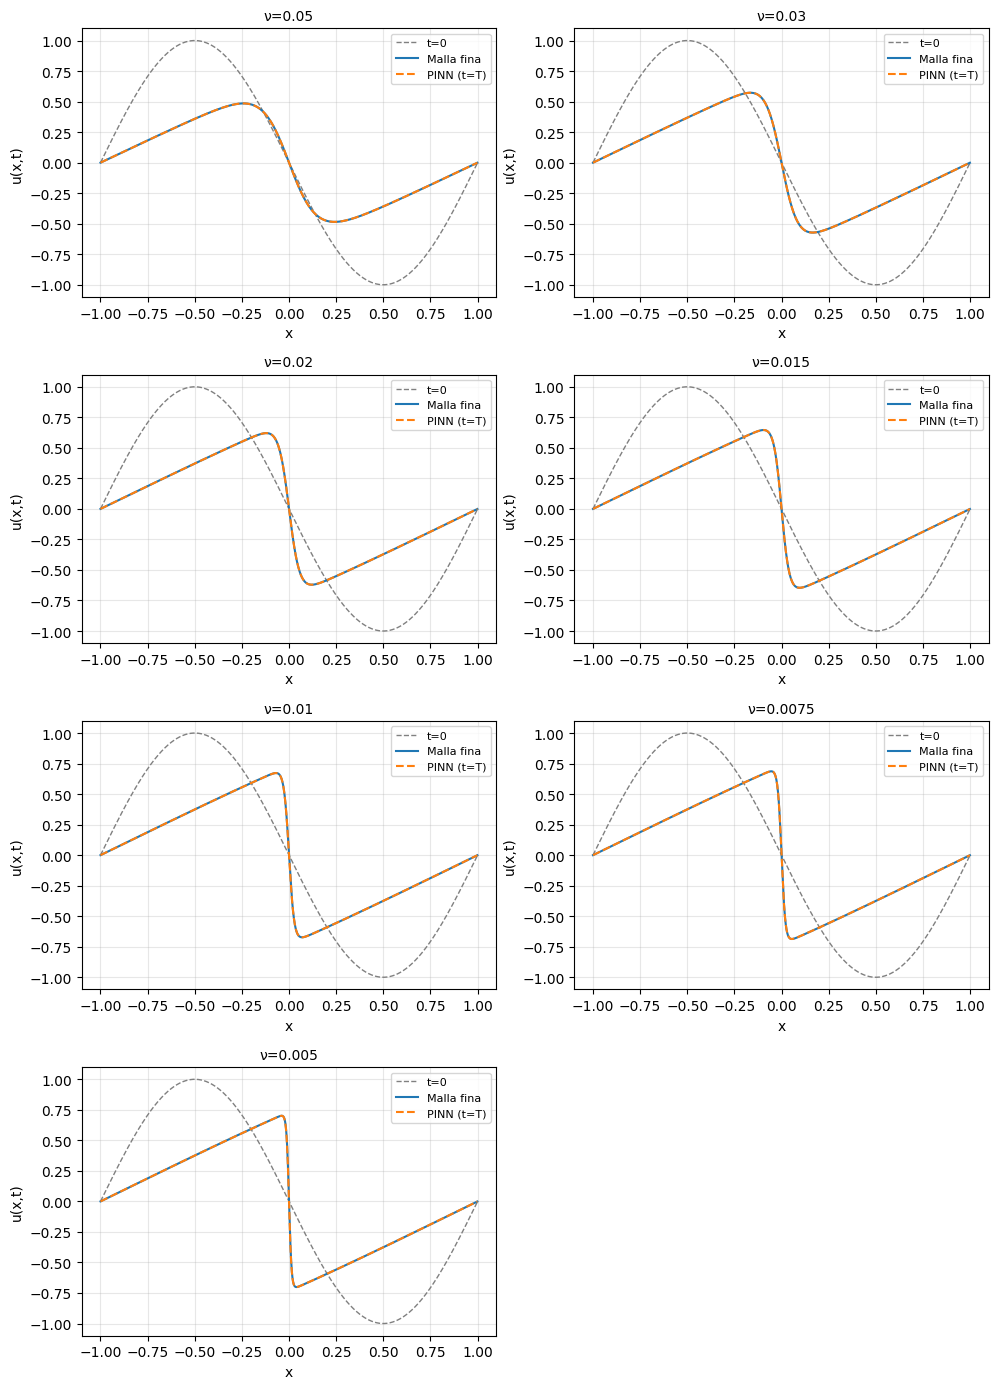

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from config import NT_BURGERS, NX_BURGERS, T_BURGERS, X_MAX_BURGERS, X_MIN_BURGERS

datos = np.load('burgers_referencias_ultimo_t.npz')
nu_valores = [0.05, 0.03, 0.02, 0.015, 0.01, 0.0075, 0.005]


fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for i, nu in enumerate(nu_valores):
    datos_pinn = np.load(f'burgers_pinn_resultado_nu{nu}.npz')
    x = datos_pinn['x']
    u_pinn = datos_pinn['u_pinn']
    err = float(datos_pinn['error_l2_pinn'])

    u0 = -np.sin(np.pi * x)

    x_ref=datos[f'x_ref_nu{nu}']
    u_ref=datos[f'u_ref_nu{nu}']

    ax = axes[i]
    ax.plot(x, u0, '--', color='gray', linewidth=1, label='t=0')
    ax.plot(x_ref, u_ref, '-', linewidth=1.5, label='Malla fina')
    ax.plot(x, u_pinn, '--', linewidth=1.5, label='PINN (t=T)')
    ax.set_title(f'ν={nu}', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Ocultar los subplots sobrantes
for j in range(len(nu_valores), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

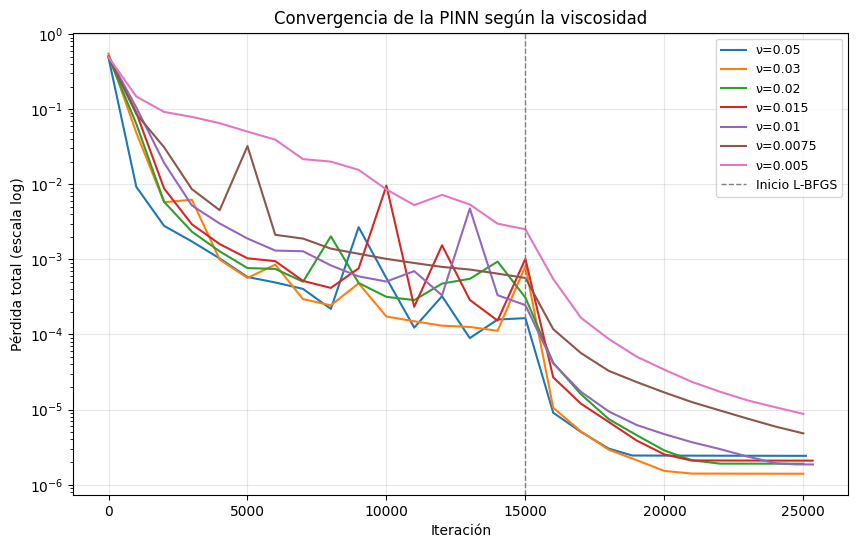

In [36]:
plt.figure(figsize=(10, 6))
for NU in nu_valores:
    datos = np.load(f'burgers_pinn_resultado_nu{NU}.npz')
    plt.plot(datos['loss_steps'], datos['loss_total'], label=f'ν={NU}', linewidth=1.5)

plt.axvline(x=15000, color='gray', linestyle='--', linewidth=1, label='Inicio L-BFGS')
plt.yscale('log')
plt.xlabel('Iteración')
plt.ylabel('Pérdida total (escala log)')
plt.title('Convergencia de la PINN según la viscosidad')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

Error de la PINN básica: 0.353395931034559
Error de la PINN mejorada: 0.06046983709352267


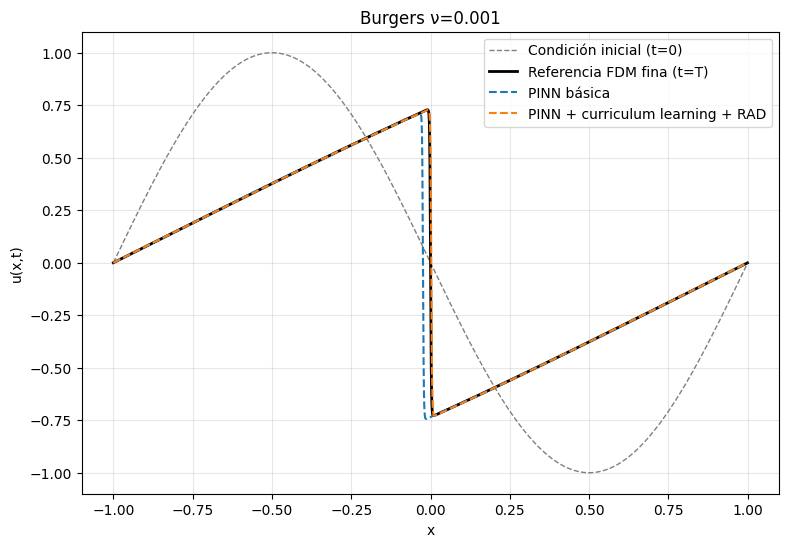

In [44]:
import numpy as np
import matplotlib.pyplot as plt

datos_ligeros = np.load('burgers_referencias_ultimo_t.npz')
x_ref = datos_ligeros['x_ref_nu0.001']
u_ref = datos_ligeros['u_ref_nu0.001']

basica = np.load('burgers_pinn_resultado_nu0.001.npz')      # ajusta nombres
mejorada = np.load('burgers_pinn_resultado_nu0.001_mejorado_v2.npz')

print(f'Error de la PINN básica: {float(basica['error_l2_pinn'])}')
print(f'Error de la PINN mejorada: {float(mejorada['error_l2_pinn'])}')

plt.figure(figsize=(9, 6))
plt.plot(x_ref, -np.sin(np.pi * x_ref), '--', color='gray', linewidth=1,
         label='Condición inicial (t=0)')
plt.plot(x_ref, u_ref, '-', color='black', linewidth=2,
         label='Referencia FDM fina (t=T)')
plt.plot(basica['x'], basica['u_pinn'], '--', linewidth=1.5,
         label=f"PINN básica")
plt.plot(mejorada['x'], mejorada['u_pinn'], '--', linewidth=1.5,
         label=f"PINN + curriculum learning + RAD")
plt.xlabel('x'); plt.ylabel('u(x,t)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Burgers ν=0.001')
plt.show()